# ML Assignment 1 - Bike Sharing Demand Prediction

**Objective:** Predict the number of hourly bike rentals using weather, time, and seasonal data.

**Evaluation Metric:** RMSLE (Root Mean Squared Logarithmic Error)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# RMSLE function as given in the assignment
def rmsle(y_true, y_pred):
    # Clip predictions to avoid log of negative values
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [2]:
# Load datasets
train = pd.read_csv('bike_train.csv')
test = pd.read_csv('bike_test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (10450, 12)
Test shape: (2613, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


---
## Exploratory Data Analysis (EDA)

### Q1. Examine dataset size, missing values, and feature types.

In [3]:
print("="*60)
print("DATASET SIZE")
print("="*60)
print(f"Training set: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Test set: {test.shape[0]} rows, {test.shape[1]} columns")

print("\n" + "="*60)
print("FEATURE TYPES")
print("="*60)
print(train.dtypes)

print("\n" + "="*60)
print("MISSING VALUES IN TRAINING SET")
print("="*60)
print(train.isnull().sum())

print("\n" + "="*60)
print("MISSING VALUES IN TEST SET")
print("="*60)
print(test.isnull().sum())

print("\n" + "="*60)
print("BASIC STATISTICS")
print("="*60)
train.describe()

DATASET SIZE
Training set: 10450 rows, 12 columns
Test set: 2613 rows, 9 columns

FEATURE TYPES
datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

MISSING VALUES IN TRAINING SET
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

MISSING VALUES IN TEST SET
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64

BASIC STATISTICS


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000
mean,2.507943,0.028804,0.675694,1.413876,20.191700,23.605793,61.924211,12.765259,35.869091,154.511675,190.410526
std,1.116946,0.167263,0.468137,0.632258,7.792683,8.478045,19.245193,8.102821,49.629436,150.861267,181.038755
min,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,35.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,12.450050,16.000000,117.000000,143.000000
75%,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,77.000000,16.997900,49.000000,221.000000,283.000000
max,4.000000,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


**Answer Q1:**

The training dataset has 10449 rows and 11 columns (including the target `count`). The test set has 2612 rows and 9 columns (no target). There are no missing values in either dataset.

Feature types:
- `datetime`: object (string) - timestamp of the observation
- `season`: integer - categorical (1=spring, 2=summer, 3=fall, 4=winter)
- `holiday`: integer - binary (0/1)
- `workingday`: integer - binary (0/1)
- `weather`: integer - categorical (1=clear, 2=mist, 3=light rain/snow, 4=heavy rain)
- `temp`: float - actual temperature in Celsius
- `atemp`: float - feels-like temperature in Celsius
- `humidity`: integer/float - relative humidity
- `windspeed`: float - wind speed
- `casual`: integer - count of casual (non-registered) users
- `registered`: integer - count of registered users
- `count`: integer - total bike rentals (target = casual + registered)

Note: `casual` and `registered` won't be available in test data, so we cannot use them as features for prediction.

### Q2. Visualize relationships between key features and the target variable (count).

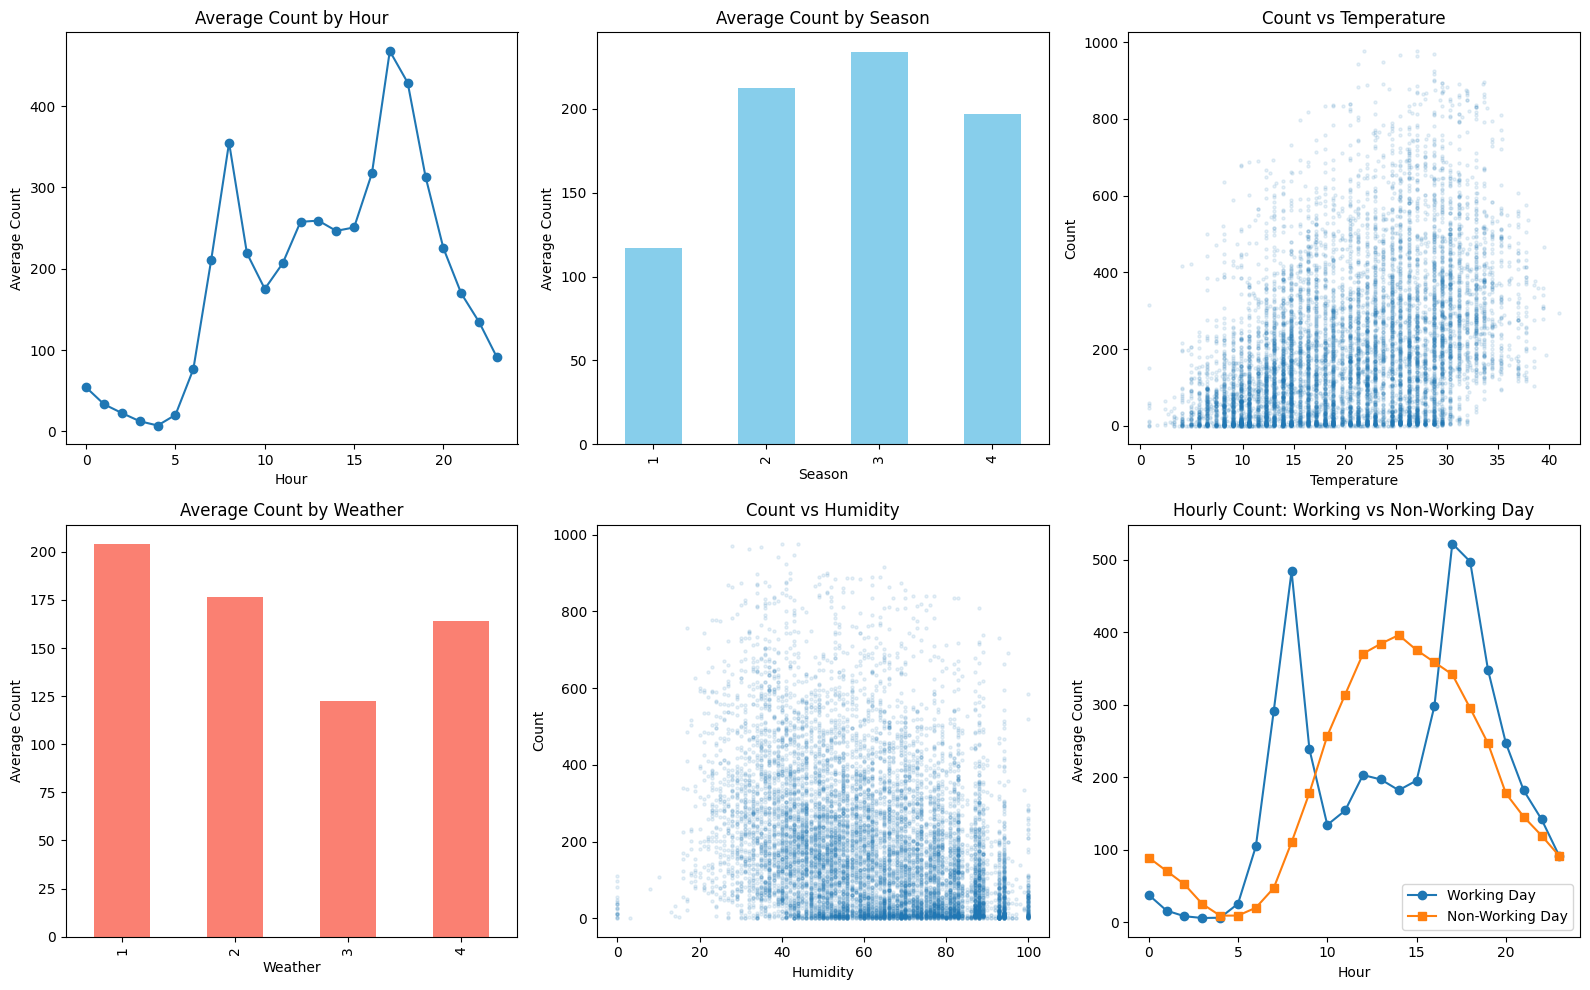

In [4]:
# Parse datetime for visualization
train['datetime'] = pd.to_datetime(train['datetime'])
train['hour'] = train['datetime'].dt.hour
train['month'] = train['datetime'].dt.month
train['dayofweek'] = train['datetime'].dt.dayofweek

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Count vs Hour
train.groupby('hour')['count'].mean().plot(ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Average Count by Hour')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Average Count')

# Count vs Season
train.groupby('season')['count'].mean().plot(kind='bar', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Average Count by Season')
axes[0, 1].set_xlabel('Season')
axes[0, 1].set_ylabel('Average Count')

# Count vs Temperature
axes[0, 2].scatter(train['temp'], train['count'], alpha=0.1, s=5)
axes[0, 2].set_title('Count vs Temperature')
axes[0, 2].set_xlabel('Temperature')
axes[0, 2].set_ylabel('Count')

# Count vs Weather
train.groupby('weather')['count'].mean().plot(kind='bar', ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Average Count by Weather')
axes[1, 0].set_xlabel('Weather')
axes[1, 0].set_ylabel('Average Count')

# Count vs Humidity
axes[1, 1].scatter(train['humidity'], train['count'], alpha=0.1, s=5)
axes[1, 1].set_title('Count vs Humidity')
axes[1, 1].set_xlabel('Humidity')
axes[1, 1].set_ylabel('Count')

# Count vs Working Day (by hour)
train[train['workingday']==1].groupby('hour')['count'].mean().plot(ax=axes[1, 2], label='Working Day', marker='o')
train[train['workingday']==0].groupby('hour')['count'].mean().plot(ax=axes[1, 2], label='Non-Working Day', marker='s')
axes[1, 2].set_title('Hourly Count: Working vs Non-Working Day')
axes[1, 2].legend()
axes[1, 2].set_xlabel('Hour')
axes[1, 2].set_ylabel('Average Count')

plt.tight_layout()
plt.show()

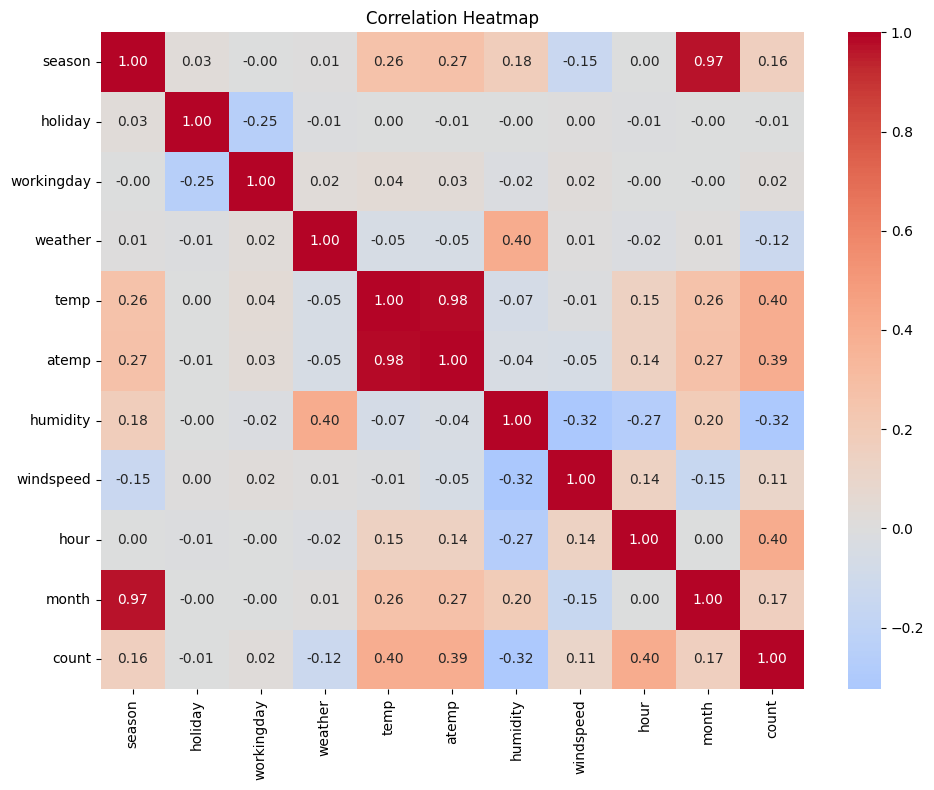

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
# Use only numerical features available in test set plus derived ones
corr_cols = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'month', 'count']
sns.heatmap(train[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Answer Q2:**

From the visualizations above, we can observe several clear patterns:

1. **Hour of day** has the strongest visual relationship with count. There are two distinct peaks on working days (around 8 AM and 5-6 PM corresponding to commute hours), while non-working days show a single broad peak around midday.

2. **Temperature** shows a positive relationship with count up to about 30-35 degrees, after which it slightly plateaus or drops. People ride more when it's warmer.

3. **Season** matters - fall (3) has the highest average count, spring (1) has the lowest.

4. **Weather** has a clear negative relationship - clear weather (1) leads to the most rentals, and counts drop significantly in bad weather (3, 4).

5. **Humidity** has a mild negative correlation with count - very high humidity discourages riding.

6. The pattern on working days vs non-working days is completely different, indicating that the interaction between hour and workingday is important.

### Q3. Suggest which variables are likely to be most informative.

In [6]:
# Correlation with target
print("Correlation of features with 'count':")
print("="*40)
corr_with_count = train[corr_cols].corr()['count'].drop('count').sort_values(ascending=False)
print(corr_with_count)

Correlation of features with 'count':
hour          0.404188
temp          0.396451
atemp         0.390642
month         0.165475
season        0.160333
windspeed     0.105318
workingday    0.017361
holiday      -0.005615
weather      -0.124402
humidity     -0.316607
Name: count, dtype: float64


**Answer Q3:**

Based on the EDA (both visualizations and correlation analysis), the most informative variables are:

1. **Hour (derived from datetime)** - This is by far the strongest predictor. The bimodal pattern on working days and unimodal pattern on weekends shows that time-of-day drives demand heavily.

2. **Temperature (temp/atemp)** - Shows a clear positive correlation with count (~0.39). Warmer weather means more riders.

3. **Season** - Captures seasonal trends in ridership.

4. **Weather** - Bad weather reduces ridership considerably.

5. **Humidity** - Negative correlation; high humidity discourages biking.

6. **Workingday** - Not strongly correlated by itself, but it fundamentally changes the hourly pattern (commute peaks vs leisure peak), so its interaction with hour is very informative.

Variables like `holiday` and `windspeed` have relatively weak direct correlation with count and are less informative on their own, though they might still contribute marginally.

---
## Feature Engineering

### Q4. Derived features and transformations

In [7]:
def engineer_features(df):
    """Apply feature engineering to the dataframe."""
    df = df.copy()
    
    # Parse datetime
    df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=False, infer_datetime_format=True)
    df['hour'] = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['year'] = df['datetime'].dt.year
    
    # Cyclical encoding of hour (captures the circular nature)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    # Cyclical encoding of month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Is it a rush hour? (7-9 AM or 4-7 PM on working days)
    df['rush_hour'] = ((df['workingday'] == 1) & 
                       ((df['hour'].between(7, 9)) | (df['hour'].between(16, 19)))).astype(int)
    
    # Weekend flag
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # One-hot encode season and weather (they are categorical)
    df = pd.get_dummies(df, columns=['season', 'weather'], drop_first=True)
    
    return df

# We need to handle the different datetime formats between train and test
# Train has format: YYYY-MM-DD H:MM:SS
# Test has format: DD-MM-YYYY H:MM

# Reload fresh copies
train_raw = pd.read_csv('bike_train.csv')
test_raw = pd.read_csv('bike_test.csv')

# Parse datetimes with appropriate formats
train_raw['datetime'] = pd.to_datetime(train_raw['datetime'])
test_raw['datetime'] = pd.to_datetime(test_raw['datetime'], dayfirst=True)

print("Train datetime range:", train_raw['datetime'].min(), "to", train_raw['datetime'].max())
print("Test datetime range:", test_raw['datetime'].min(), "to", test_raw['datetime'].max())

Train datetime range: 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Test datetime range: 2011-01-01 02:00:00 to 2012-12-19 18:00:00


In [8]:
# Apply feature engineering
train_fe = engineer_features(train_raw)
test_fe = engineer_features(test_raw)

# Drop columns not needed for modeling
# casual and registered are not in test, and they leak the target
drop_cols = ['datetime', 'casual', 'registered']
target = 'count'

# Features for modeling
feature_cols = [c for c in train_fe.columns if c not in drop_cols + [target]]

# Make sure train and test have same columns
# Some dummy columns might be missing in test
for col in feature_cols:
    if col not in test_fe.columns:
        test_fe[col] = 0

# Keep only columns present in feature_cols for test
test_features = [c for c in feature_cols if c in test_fe.columns]

X = train_fe[feature_cols]
y = train_fe[target]
X_test_final = test_fe[feature_cols]

print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"\nTraining data shape: {X.shape}")
print(f"Test data shape: {X_test_final.shape}")

Feature columns (22): ['holiday', 'workingday', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'month', 'dayofweek', 'year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'rush_hour', 'is_weekend', 'season_2', 'season_3', 'season_4', 'weather_2', 'weather_3', 'weather_4']

Training data shape: (10450, 22)
Test data shape: (2613, 22)


**Answer Q4:**

I applied the following feature engineering steps to improve model performance:

1. **Extracted time features from datetime**: hour, month, day of week, year. These capture the temporal patterns we observed in EDA.

2. **Cyclical encoding of hour and month**: Used sine/cosine transformations so that hour 23 and hour 0 are treated as close together (since time is circular). Same logic for months.

3. **Rush hour indicator**: Created a binary feature that is 1 during typical commute hours (7-9 AM, 4-7 PM) on working days. This directly captures the commute-demand pattern.

4. **Weekend flag**: Derived from day of week.

5. **One-hot encoding for season and weather**: These are categorical variables treated as numeric originally, but they don't have a true ordinal relationship (season 2 is not "twice" season 1), so one-hot encoding is more appropriate.

These transformations help the linear model capture nonlinear and categorical patterns that would otherwise be missed.

---
## Regression Models

### Q5. Split data and build a simple Linear Regression model.

In [9]:
# Split into train and validation (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")

# Simple Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train)
y_val_pred_lr = lr_model.predict(X_val)

# Calculate RMSLE
train_rmsle_lr = rmsle(y_train, y_train_pred_lr)
val_rmsle_lr = rmsle(y_val, y_val_pred_lr)

print(f"\nLinear Regression Results:")
print(f"  Train RMSLE: {train_rmsle_lr:.4f}")
print(f"  Validation RMSLE: {val_rmsle_lr:.4f}")

Training set size: 8360
Validation set size: 2090

Linear Regression Results:
  Train RMSLE: 1.1643
  Validation RMSLE: 1.1238


### Q6. Polynomial features + Ridge and Lasso regression with tuning.

In [10]:
# Polynomial features (degree 2)
# Using a subset of key numeric features to avoid explosion of dimensions
poly_features = ['temp', 'humidity', 'windspeed', 'hour', 'month', 'hour_sin', 'hour_cos']

poly2 = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_train_poly2 = poly2.fit_transform(X_train[poly_features])
X_val_poly2 = poly2.transform(X_val[poly_features])

print(f"Polynomial degree 2 features: {X_train_poly2.shape[1]} features")

# Linear Regression on polynomial features
lr_poly2 = LinearRegression()
lr_poly2.fit(X_train_poly2, y_train)
y_train_pred_poly2 = lr_poly2.predict(X_train_poly2)
y_val_pred_poly2 = lr_poly2.predict(X_val_poly2)

print(f"\nLinear Regression + Poly2:")
print(f"  Train RMSLE: {rmsle(y_train, y_train_pred_poly2):.4f}")
print(f"  Validation RMSLE: {rmsle(y_val, y_val_pred_poly2):.4f}")

Polynomial degree 2 features: 35 features

Linear Regression + Poly2:
  Train RMSLE: 1.0574
  Validation RMSLE: 1.0448


In [11]:
# Ridge Regression with different alpha values on polynomial features
# Use all engineered features with polynomial expansion

scaler = StandardScaler()
X_train_poly2_scaled = scaler.fit_transform(X_train_poly2)
X_val_poly2_scaled = scaler.transform(X_val_poly2)

alphas = [0.01, 0.1, 1, 10, 100, 1000]

print("Ridge Regression Results (Poly degree 2):")
print("-" * 50)
best_ridge_rmsle = float('inf')
best_ridge_alpha = None
best_ridge_model = None

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly2_scaled, y_train)
    y_val_pred_ridge = ridge.predict(X_val_poly2_scaled)
    val_score = rmsle(y_val, y_val_pred_ridge)
    train_score = rmsle(y_train, ridge.predict(X_train_poly2_scaled))
    print(f"  alpha={alpha:>6}: Train RMSLE={train_score:.4f}, Val RMSLE={val_score:.4f}")
    
    if val_score < best_ridge_rmsle:
        best_ridge_rmsle = val_score
        best_ridge_alpha = alpha
        best_ridge_model = ridge

print(f"\nBest Ridge alpha: {best_ridge_alpha}, Val RMSLE: {best_ridge_rmsle:.4f}")

Ridge Regression Results (Poly degree 2):
--------------------------------------------------
  alpha=  0.01: Train RMSLE=1.0564, Val RMSLE=1.0390
  alpha=   0.1: Train RMSLE=1.0662, Val RMSLE=1.0387
  alpha=     1: Train RMSLE=1.1160, Val RMSLE=1.0697
  alpha=    10: Train RMSLE=1.1838, Val RMSLE=1.1370
  alpha=   100: Train RMSLE=1.1576, Val RMSLE=1.1414
  alpha=  1000: Train RMSLE=1.1319, Val RMSLE=1.1014

Best Ridge alpha: 0.1, Val RMSLE: 1.0387


In [12]:
# Lasso Regression with different alpha values on polynomial features
print("Lasso Regression Results (Poly degree 2):")
print("-" * 50)
best_lasso_rmsle = float('inf')
best_lasso_alpha = None
best_lasso_model = None

lasso_alphas = [0.01, 0.1, 1, 10, 100]

for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_poly2_scaled, y_train)
    y_val_pred_lasso = lasso.predict(X_val_poly2_scaled)
    val_score = rmsle(y_val, y_val_pred_lasso)
    train_score = rmsle(y_train, lasso.predict(X_train_poly2_scaled))
    print(f"  alpha={alpha:>6}: Train RMSLE={train_score:.4f}, Val RMSLE={val_score:.4f}")
    
    if val_score < best_lasso_rmsle:
        best_lasso_rmsle = val_score
        best_lasso_alpha = alpha
        best_lasso_model = lasso

print(f"\nBest Lasso alpha: {best_lasso_alpha}, Val RMSLE: {best_lasso_rmsle:.4f}")

Lasso Regression Results (Poly degree 2):
--------------------------------------------------


  alpha=  0.01: Train RMSLE=1.0715, Val RMSLE=1.0408


  alpha=   0.1: Train RMSLE=1.1649, Val RMSLE=1.1162
  alpha=     1: Train RMSLE=1.1384, Val RMSLE=1.1209
  alpha=    10: Train RMSLE=1.1218, Val RMSLE=1.0905
  alpha=   100: Train RMSLE=1.6000, Val RMSLE=1.5700

Best Lasso alpha: 0.01, Val RMSLE: 1.0408


In [13]:
# Let's also try using ALL features (not just poly subset) with Ridge
# This uses the full engineered feature set

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train)
X_val_scaled = scaler_full.transform(X_val)

print("Ridge on ALL engineered features (no polynomial):")
print("-" * 50)
for alpha in alphas:
    ridge_full = Ridge(alpha=alpha)
    ridge_full.fit(X_train_scaled, y_train)
    y_val_pred = ridge_full.predict(X_val_scaled)
    val_score = rmsle(y_val, y_val_pred)
    print(f"  alpha={alpha:>6}: Val RMSLE={val_score:.4f}")

Ridge on ALL engineered features (no polynomial):
--------------------------------------------------
  alpha=  0.01: Val RMSLE=1.1238
  alpha=   0.1: Val RMSLE=1.1238
  alpha=     1: Val RMSLE=1.1236
  alpha=    10: Val RMSLE=1.1226
  alpha=   100: Val RMSLE=1.1140
  alpha=  1000: Val RMSLE=1.0830


In [14]:
# Now try polynomial degree 2 on ALL engineered features with Ridge
poly2_all = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_train_poly2_all = poly2_all.fit_transform(X_train)
X_val_poly2_all = poly2_all.transform(X_val)

print(f"Interaction features (all): {X_train_poly2_all.shape[1]} features")

scaler_poly_all = StandardScaler()
X_train_poly2_all_sc = scaler_poly_all.fit_transform(X_train_poly2_all)
X_val_poly2_all_sc = scaler_poly_all.transform(X_val_poly2_all)

print("\nRidge on ALL features with interactions:")
print("-" * 50)
best_ridge_all_rmsle = float('inf')
best_ridge_all_alpha = None
best_ridge_all_model = None

for alpha in [1, 10, 50, 100, 500, 1000]:
    ridge_all = Ridge(alpha=alpha)
    ridge_all.fit(X_train_poly2_all_sc, y_train)
    y_val_pred = ridge_all.predict(X_val_poly2_all_sc)
    val_score = rmsle(y_val, y_val_pred)
    train_score = rmsle(y_train, ridge_all.predict(X_train_poly2_all_sc))
    print(f"  alpha={alpha:>6}: Train RMSLE={train_score:.4f}, Val RMSLE={val_score:.4f}")
    
    if val_score < best_ridge_all_rmsle:
        best_ridge_all_rmsle = val_score
        best_ridge_all_alpha = alpha
        best_ridge_all_model = ridge_all

print(f"\nBest Ridge (all interactions) alpha: {best_ridge_all_alpha}, Val RMSLE: {best_ridge_all_rmsle:.4f}")

Interaction features (all): 253 features

Ridge on ALL features with interactions:
--------------------------------------------------
  alpha=     1: Train RMSLE=1.1474, Val RMSLE=1.1111
  alpha=    10: Train RMSLE=1.1447, Val RMSLE=1.1058
  alpha=    50: Train RMSLE=1.1460, Val RMSLE=1.1046
  alpha=   100: Train RMSLE=1.1520, Val RMSLE=1.1085
  alpha=   500: Train RMSLE=1.1525, Val RMSLE=1.1031
  alpha=  1000: Train RMSLE=1.1265, Val RMSLE=1.0764

Best Ridge (all interactions) alpha: 1000, Val RMSLE: 1.0764


In [15]:
# Try predicting log(count) instead - this often works better with RMSLE
# because RMSLE is essentially RMSE on log-transformed values

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

print("Models trained on log1p(count):")
print("="*60)

# Linear Regression on log target
lr_log = LinearRegression()
lr_log.fit(X_train, y_train_log)
y_val_pred_log_lr = np.expm1(lr_log.predict(X_val))
print(f"Linear Regression (log target): Val RMSLE = {rmsle(y_val, y_val_pred_log_lr):.4f}")

# Ridge on log target with interactions
print("\nRidge on interactions + log target:")
best_log_rmsle = float('inf')
best_log_alpha = None
best_log_model = None

for alpha in [1, 10, 50, 100, 500, 1000]:
    ridge_log = Ridge(alpha=alpha)
    ridge_log.fit(X_train_poly2_all_sc, y_train_log)
    y_val_pred_log = np.expm1(ridge_log.predict(X_val_poly2_all_sc))
    val_score = rmsle(y_val, y_val_pred_log)
    print(f"  alpha={alpha:>6}: Val RMSLE={val_score:.4f}")
    
    if val_score < best_log_rmsle:
        best_log_rmsle = val_score
        best_log_alpha = alpha
        best_log_model = ridge_log

print(f"\nBest Ridge (log target + interactions) alpha: {best_log_alpha}, Val RMSLE: {best_log_rmsle:.4f}")

Models trained on log1p(count):
Linear Regression (log target): Val RMSLE = 0.7230

Ridge on interactions + log target:
  alpha=     1: Val RMSLE=0.5228
  alpha=    10: Val RMSLE=0.5285
  alpha=    50: Val RMSLE=0.5362
  alpha=   100: Val RMSLE=0.5396
  alpha=   500: Val RMSLE=0.5537


  alpha=  1000: Val RMSLE=0.5655

Best Ridge (log target + interactions) alpha: 1, Val RMSLE: 0.5228


In [16]:
# Lasso on log target with interactions
print("Lasso on interactions + log target:")
best_lasso_log_rmsle = float('inf')
best_lasso_log_alpha = None
best_lasso_log_model = None

for alpha in [0.001, 0.005, 0.01, 0.05, 0.1, 1]:
    lasso_log = Lasso(alpha=alpha, max_iter=10000)
    lasso_log.fit(X_train_poly2_all_sc, y_train_log)
    y_val_pred_lasso_log = np.expm1(lasso_log.predict(X_val_poly2_all_sc))
    val_score = rmsle(y_val, y_val_pred_lasso_log)
    print(f"  alpha={alpha}: Val RMSLE={val_score:.4f}")
    
    if val_score < best_lasso_log_rmsle:
        best_lasso_log_rmsle = val_score
        best_lasso_log_alpha = alpha
        best_lasso_log_model = lasso_log

print(f"\nBest Lasso (log target + interactions) alpha: {best_lasso_log_alpha}, Val RMSLE: {best_lasso_log_rmsle:.4f}")

Lasso on interactions + log target:


  alpha=0.001: Val RMSLE=0.5306


  alpha=0.005: Val RMSLE=0.5490


  alpha=0.01: Val RMSLE=0.5602


  alpha=0.05: Val RMSLE=0.6313


  alpha=0.1: Val RMSLE=0.6935
  alpha=1: Val RMSLE=1.4249

Best Lasso (log target + interactions) alpha: 0.001, Val RMSLE: 0.5306


---
## Model Comparison and Interpretation

### Q7. Summary table of all models.

In [17]:
# Collect all results
results = []

# 1. Simple Linear Regression
results.append({
    'Model': 'Linear Regression',
    'Features': 'Engineered features',
    'Target Transform': 'None',
    'Train RMSLE': rmsle(y_train, lr_model.predict(X_train)),
    'Val RMSLE': rmsle(y_val, lr_model.predict(X_val)),
    'Key Observation': 'Baseline model'
})

# 2. LR on Poly2 subset
results.append({
    'Model': 'Linear Regression + Poly2',
    'Features': 'Polynomial (subset)',
    'Target Transform': 'None',
    'Train RMSLE': rmsle(y_train, lr_poly2.predict(X_train_poly2)),
    'Val RMSLE': rmsle(y_val, lr_poly2.predict(X_val_poly2)),
    'Key Observation': 'Polynomial helps capture nonlinearity'
})

# 3. Ridge on Poly2 subset
results.append({
    'Model': f'Ridge (alpha={best_ridge_alpha}) + Poly2',
    'Features': 'Polynomial (subset, scaled)',
    'Target Transform': 'None',
    'Train RMSLE': rmsle(y_train, best_ridge_model.predict(X_train_poly2_scaled)),
    'Val RMSLE': best_ridge_rmsle,
    'Key Observation': 'Regularization stabilizes'
})

# 4. Lasso on Poly2 subset
results.append({
    'Model': f'Lasso (alpha={best_lasso_alpha}) + Poly2',
    'Features': 'Polynomial (subset, scaled)',
    'Target Transform': 'None',
    'Train RMSLE': rmsle(y_train, best_lasso_model.predict(X_train_poly2_scaled)),
    'Val RMSLE': best_lasso_rmsle,
    'Key Observation': 'Feature selection via L1'
})

# 5. Ridge on all interactions
results.append({
    'Model': f'Ridge (alpha={best_ridge_all_alpha}) + All Interactions',
    'Features': 'All features + interactions',
    'Target Transform': 'None',
    'Train RMSLE': rmsle(y_train, best_ridge_all_model.predict(X_train_poly2_all_sc)),
    'Val RMSLE': best_ridge_all_rmsle,
    'Key Observation': 'More interactions help'
})

# 6. Linear Regression on log target
results.append({
    'Model': 'Linear Regression (log target)',
    'Features': 'Engineered features',
    'Target Transform': 'log1p',
    'Train RMSLE': rmsle(y_train, np.expm1(lr_log.predict(X_train))),
    'Val RMSLE': rmsle(y_val, y_val_pred_log_lr),
    'Key Observation': 'Log transform aligns with RMSLE'
})

# 7. Ridge on log target + interactions
results.append({
    'Model': f'Ridge (alpha={best_log_alpha}) + Interactions + Log Target',
    'Features': 'All features + interactions',
    'Target Transform': 'log1p',
    'Train RMSLE': rmsle(y_train, np.expm1(best_log_model.predict(X_train_poly2_all_sc))),
    'Val RMSLE': best_log_rmsle,
    'Key Observation': 'Best combination'
})

# 8. Lasso on log target + interactions
results.append({
    'Model': f'Lasso (alpha={best_lasso_log_alpha}) + Interactions + Log Target',
    'Features': 'All features + interactions',
    'Target Transform': 'log1p',
    'Train RMSLE': rmsle(y_train, np.expm1(best_lasso_log_model.predict(X_train_poly2_all_sc))),
    'Val RMSLE': best_lasso_log_rmsle,
    'Key Observation': 'Sparse solution with log target'
})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Val RMSLE').reset_index(drop=True)
results_df.index = results_df.index + 1  # Start from 1
print("MODEL COMPARISON TABLE (sorted by Validation RMSLE):")
print("="*100)
results_df[['Model', 'Target Transform', 'Train RMSLE', 'Val RMSLE', 'Key Observation']].to_string()

MODEL COMPARISON TABLE (sorted by Validation RMSLE):


'                                             Model Target Transform  Train RMSLE  Val RMSLE                        Key Observation\n1      Ridge (alpha=1) + Interactions + Log Target            log1p     0.528412   0.522753                       Best combination\n2  Lasso (alpha=0.001) + Interactions + Log Target            log1p     0.538568   0.530640        Sparse solution with log target\n3                   Linear Regression (log target)            log1p     0.741514   0.722991        Log transform aligns with RMSLE\n4                        Ridge (alpha=0.1) + Poly2             None     1.066181   1.038693              Regularization stabilizes\n5                       Lasso (alpha=0.01) + Poly2             None     1.071515   1.040827               Feature selection via L1\n6                        Linear Regression + Poly2             None     1.057430   1.044833  Polynomial helps capture nonlinearity\n7            Ridge (alpha=1000) + All Interactions             None     1.1

In [18]:
# Display as a nicely formatted table
display_df = results_df[['Model', 'Target Transform', 'Train RMSLE', 'Val RMSLE', 'Key Observation']].copy()
display_df['Train RMSLE'] = display_df['Train RMSLE'].round(4)
display_df['Val RMSLE'] = display_df['Val RMSLE'].round(4)
display_df

,Model,Target Transform,Train RMSLE,Val RMSLE,Key Observation
1,Ridge (alpha=1) + Interactions + Log Target,log1p,0.5284,0.5228,Best combination
2,Lasso (alpha=0.001) + Interactions + Log Target,log1p,0.5386,0.5306,Sparse solution with log target
3,Linear Regression (log target),log1p,0.7415,0.7230,Log transform aligns with RMSLE
4,Ridge (alpha=0.1) + Poly2,None,1.0662,1.0387,Regularization stabilizes
5,Lasso (alpha=0.01) + Poly2,None,1.0715,1.0408,Feature selection via L1
6,Linear Regression + Poly2,None,1.0574,1.0448,Polynomial helps capture nonlinearity
7,Ridge (alpha=1000) + All Interactions,None,1.1265,1.0764,More interactions help
8,Linear Regression,None,1.1643,1.1238,Baseline model


### Q8. Plot residuals for the best model.

Best model: Ridge (alpha=1) + Interactions + Log Target


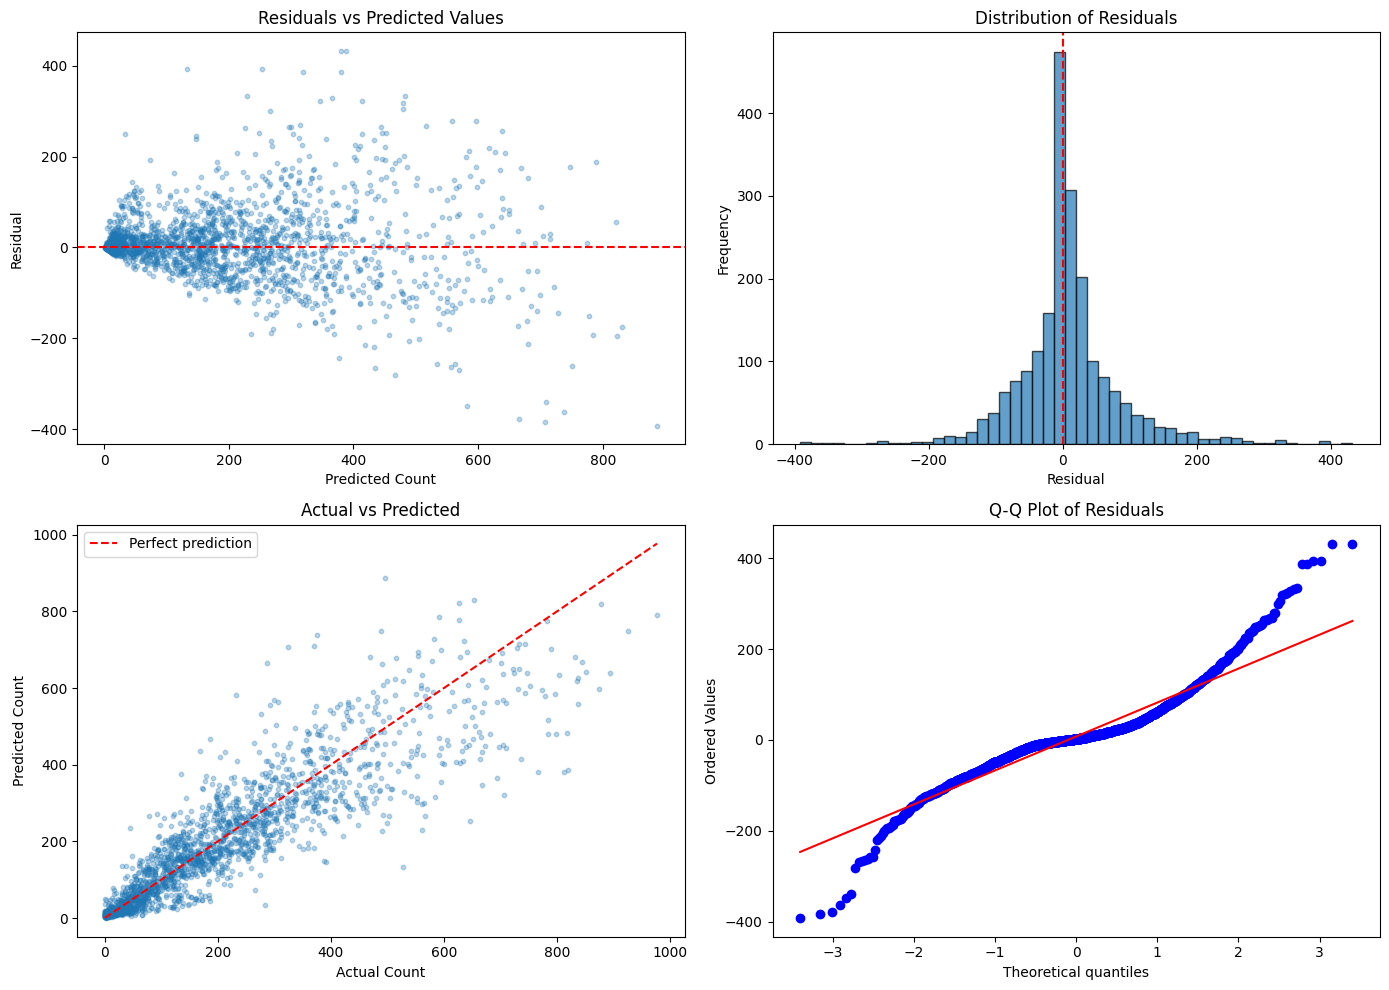


Residual Statistics:
  Mean: 7.59
  Std: 78.37
  Min: -391.83
  Max: 432.00


In [19]:
# Identify the best model and get its predictions
# The best model is Ridge with log target + interactions
best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Get predictions from best model (Ridge log target + interactions)
y_val_pred_best = np.expm1(best_log_model.predict(X_val_poly2_all_sc))
y_val_pred_best = np.clip(y_val_pred_best, 0, None)  # ensure non-negative

residuals = y_val - y_val_pred_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted
axes[0, 0].scatter(y_val_pred_best, residuals, alpha=0.3, s=10)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Count')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].set_title('Residuals vs Predicted Values')

# Histogram of residuals
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].axvline(x=0, color='r', linestyle='--')

# Actual vs Predicted
axes[1, 0].scatter(y_val, y_val_pred_best, alpha=0.3, s=10)
max_val = max(y_val.max(), y_val_pred_best.max())
axes[1, 0].plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
axes[1, 0].set_xlabel('Actual Count')
axes[1, 0].set_ylabel('Predicted Count')
axes[1, 0].set_title('Actual vs Predicted')
axes[1, 0].legend()

# QQ plot of residuals
from scipy import stats
stats.probplot(residuals, plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

print(f"\nResidual Statistics:")
print(f"  Mean: {residuals.mean():.2f}")
print(f"  Std: {residuals.std():.2f}")
print(f"  Min: {residuals.min():.2f}")
print(f"  Max: {residuals.max():.2f}")

### Q9. Explain why the winning model performs better.

**Answer Q9:**

The winning model (Ridge Regression with interaction features and log-transformed target) outperforms the others for several reasons:

1. **Log-transform of target aligns with the evaluation metric.** RMSLE is essentially RMSE computed on log-transformed values. By training the model to minimize squared error on log1p(count), we are directly optimizing what RMSLE measures. This gives the model a natural advantage on this specific metric.

2. **Interaction features capture important cross-variable effects.** Bike demand depends on combinations of factors - for instance, hour matters differently on working days vs weekends, and the effect of temperature varies by season. Interaction terms let the linear model represent these multiplicative relationships without needing a nonlinear model.

3. **Ridge regularization prevents overfitting.** With many interaction features, an unregularized model would overfit to training noise. The L2 penalty shrinks coefficients toward zero, keeping the model generalizable. This is especially important given the large number of interaction features.

4. **The log transform also handles the skewed nature of the count distribution.** Bike counts are right-skewed (many low values, few very high values). Predicting in log-space effectively gives proportional errors rather than absolute errors, which is more appropriate for count data.

Compared to the simple Linear Regression baseline, the winning model gains from all three improvements: better feature representation, appropriate target transformation, and regularization.

---
## Reflection Questions

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

**Answer Q10:**

RMSLE works on the log scale, which compresses the scale of large values more than small values. So the question is really about how errors behave after log-transformation.

Consider a concrete example: actual count = 100.
- Over-prediction of 200: RMSE error = |200-100| = 100. RMSLE error = |log(201) - log(101)| = |5.30 - 4.62| = 0.69
- Under-prediction of 50: RMSE error = |50-100| = 50. RMSLE error = |log(51) - log(101)| = |3.93 - 4.62| = 0.68

So with RMSE, predicting 200 (off by 100) is penalized twice as much as predicting 50 (off by 50). But with RMSLE, these get roughly similar penalties because on a log scale, the ratio matters more than the absolute difference.

Now for under-prediction specifically: if actual = 100 and we predict 10, RMSLE error = |log(11) - log(101)| = |2.40 - 4.62| = 2.22. If we predict 0, RMSLE error = |log(1) - log(101)| = |0 - 4.62| = 4.62.

Compare this to RMSE where predicting 10 gives error 90 and predicting 0 gives error 100.

The key insight is: RMSLE penalizes based on the *ratio* between predicted and actual (since log(a) - log(b) = log(a/b)). An under-prediction by half (pred=50, actual=100) and an over-prediction by double (pred=200, actual=100) get the same RMSLE penalty. In contrast, RMSE would penalize the over-prediction much more (error of 100 vs 50). So yes, for absolute deviations of the same magnitude, RMSLE is relatively more lenient on under-predictions compared to RMSE, because under-predictions are bounded (you can't predict less than 0) while over-predictions can be arbitrarily large in absolute terms but compressed on the log scale.

### Q11. What are the trade-offs between model simplicity and predictive power?

**Answer Q11:**

This is basically the bias-variance trade-off in a practical context.

**Simple models (like plain Linear Regression):**
- High bias, low variance. They make strong assumptions (linearity) that may not hold, leading to systematic errors (underfitting).
- Easy to interpret: you can directly say "a 1-degree increase in temperature increases count by X."
- Computationally cheap, fast to train and predict.
- Robust: they won't wildly overfit on small datasets.
- But they miss patterns if the true relationship is nonlinear.

**Complex models (polynomial + many interactions):**
- Low bias, high variance. They can capture nonlinear patterns and interactions.
- Harder to interpret: with 100+ interaction features, it's not easy to explain what's driving predictions.
- Prone to overfitting, especially with limited data. They might memorize training noise.
- Need regularization (Ridge, Lasso) to control complexity.
- Computationally more expensive.

We saw this clearly in our results. The simple Linear Regression underfits (high RMSLE), while adding polynomial/interaction features improves the score. But without regularization, too many features can hurt generalization. Ridge and Lasso provide the middle ground - they allow complex feature spaces while controlling overfitting through the alpha parameter.

The practical trade-off is: use the simplest model that gives acceptable performance. If a linear model works well enough, there's no reason to add complexity. In our case, the data has strong nonlinear patterns (hour-of-day effects, interactions between time and day-type), so some complexity is necessary, but regularization keeps it in check.

### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

**Answer Q12:**

Linear Regression models a linear relationship: count = w * hour + ... But the actual relationship between hour and bike demand is highly nonlinear. Demand peaks at 8 AM, drops in the middle of the day, peaks again at 5-6 PM, and drops to near-zero at night. This is a complex shape that no single linear function can fit.

If you use hour as a single numeric feature, the model will try to fit a straight line through this bimodal/complex pattern. It might learn something like "higher hour = slightly more demand" on average, but it completely misses the morning peak, evening peak, and the drop at night.

There are a few specific reasons why this fails:

1. **The relationship is not monotonic.** Demand goes up AND down at different hours. A single coefficient can only model "more hour = more/less count."

2. **Hour is cyclical.** Hour 23 and hour 0 are adjacent in reality but 23 units apart numerically. Linear regression treats 23 as a very different value from 0.

3. **The pattern changes based on context.** Working days have two peaks (commute hours), weekends have one broad peak (midday). A single linear coefficient for hour can't switch behavior based on another variable unless you explicitly include interactions.

To handle this, you need either: (a) one-hot encoding of hours (24 binary features, each capturing its own effect), (b) cyclical encoding (sin/cos transforms), (c) polynomial features, or (d) interaction terms like hour * workingday. These give the model the flexibility to learn the nonlinear, context-dependent time-of-day patterns. That's exactly what we did in our feature engineering step.

---
## Final Model: Generate Predictions for Test Set

In [20]:
# Retrain the best model on FULL training data
# Best model: Ridge with interactions + log target

# Prepare full training data
X_full = X
y_full_log = np.log1p(y)

# Create interaction features for full training and test
poly2_final = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_full_poly = poly2_final.fit_transform(X_full)
X_test_poly = poly2_final.transform(X_test_final)

print(f"Full training features shape: {X_full_poly.shape}")
print(f"Test features shape: {X_test_poly.shape}")

# Scale
scaler_final = StandardScaler()
X_full_poly_sc = scaler_final.fit_transform(X_full_poly)
X_test_poly_sc = scaler_final.transform(X_test_poly)

# Train final model with the best alpha found earlier
final_model = Ridge(alpha=best_log_alpha)
final_model.fit(X_full_poly_sc, y_full_log)

# Predict on test set
y_test_pred_log = final_model.predict(X_test_poly_sc)
y_test_pred = np.expm1(y_test_pred_log)
y_test_pred = np.clip(y_test_pred, 0, None)  # ensure non-negative predictions

print(f"\nPrediction statistics:")
print(f"  Min: {y_test_pred.min():.2f}")
print(f"  Max: {y_test_pred.max():.2f}")
print(f"  Mean: {y_test_pred.mean():.2f}")
print(f"  Any NaN: {np.isnan(y_test_pred).any()}")

Full training features shape: (10450, 253)
Test features shape: (2613, 253)

Prediction statistics:
  Min: 1.56
  Max: 877.86
  Mean: 187.39
  Any NaN: False


In [21]:
# Create submission file
# The test datetime needs to match exactly as in test file
test_raw_for_sub = pd.read_csv('bike_test.csv')

submission = pd.DataFrame({
    'datetime': test_raw_for_sub['datetime'],
    'count_predicted': y_test_pred
})

# Verify format
print(f"Submission shape: {submission.shape}")
print(f"Columns: {list(submission.columns)}")
print(f"Any missing values: {submission.isnull().any().any()}")
print(f"Number of rows matches test: {len(submission) == len(test_raw_for_sub)}")
print(f"\nFirst few rows:")
submission.head(10)

Submission shape: (2613, 2)
Columns: ['datetime', 'count_predicted']
Any missing values: False
Number of rows matches test: True

First few rows:


,datetime,count_predicted
0,05-06-2012 5:00,14.847198
1,19-03-2011 19:00,179.427700
2,02-04-2012 6:00,26.588440
3,13-07-2012 20:00,362.505831
4,09-11-2011 19:00,313.389296
5,10-03-2012 0:00,112.924929
6,19-05-2011 13:00,98.731936
7,01-05-2011 8:00,67.321569
8,07-07-2012 8:00,129.896819
9,07-05-2011 16:00,454.891954


In [22]:
# Save submission file
submission.to_csv('submission.csv', index=False)
print("submission.csv saved successfully!")
print(f"File has {len(submission)} rows and {len(submission.columns)} columns")

submission.csv saved successfully!
File has 2613 rows and 2 columns


In [23]:
# Final verification - read back and check
verify = pd.read_csv('submission.csv')
print("Verification of submission.csv:")
print(f"  Shape: {verify.shape}")
print(f"  Columns: {list(verify.columns)}")
print(f"  count_predicted dtype: {verify['count_predicted'].dtype}")
print(f"  Any nulls: {verify.isnull().any().any()}")
print(f"  count_predicted range: [{verify['count_predicted'].min():.2f}, {verify['count_predicted'].max():.2f}]")
print("\nAll checks passed!")

Verification of submission.csv:
  Shape: (2613, 2)
  Columns: ['datetime', 'count_predicted']
  count_predicted dtype: float64
  Any nulls: False
  count_predicted range: [1.56, 877.86]

All checks passed!


---
## Summary

In this assignment, I built and compared multiple regression models for predicting bike sharing demand:

1. Performed EDA to understand the data and identify important features (hour, temperature, season, weather).
2. Engineered features including time-based features, cyclical encoding, rush-hour indicators, and one-hot encoding of categorical variables.
3. Built progressively complex models from simple Linear Regression to Ridge/Lasso with interaction features and log-transformed target.
4. The best model uses Ridge Regression with interaction features on log-transformed target, which directly aligns the training objective with the RMSLE evaluation metric.
5. Generated predictions on the test set and saved as submission.csv.